In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_classification
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import v_measure_score
import seaborn as sns

1. Сгенерировать себе 2D набор данных используя встроенные функции sklearn


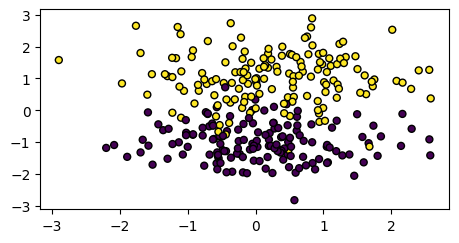

In [2]:
plt.figure(figsize=(10, 8))
plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)

plt.subplot(324)
# plt.title("Multi-class, two informative features, one cluster", fontsize="small")
X, Y_true = make_classification(n_samples=300, n_features=5, n_informative=2,
                                 n_redundant=0, n_clusters_per_class=1, random_state=42)
plt.scatter(X[:, 0], X[:, 1], marker="o", c=Y_true, s=25, edgecolor="k")

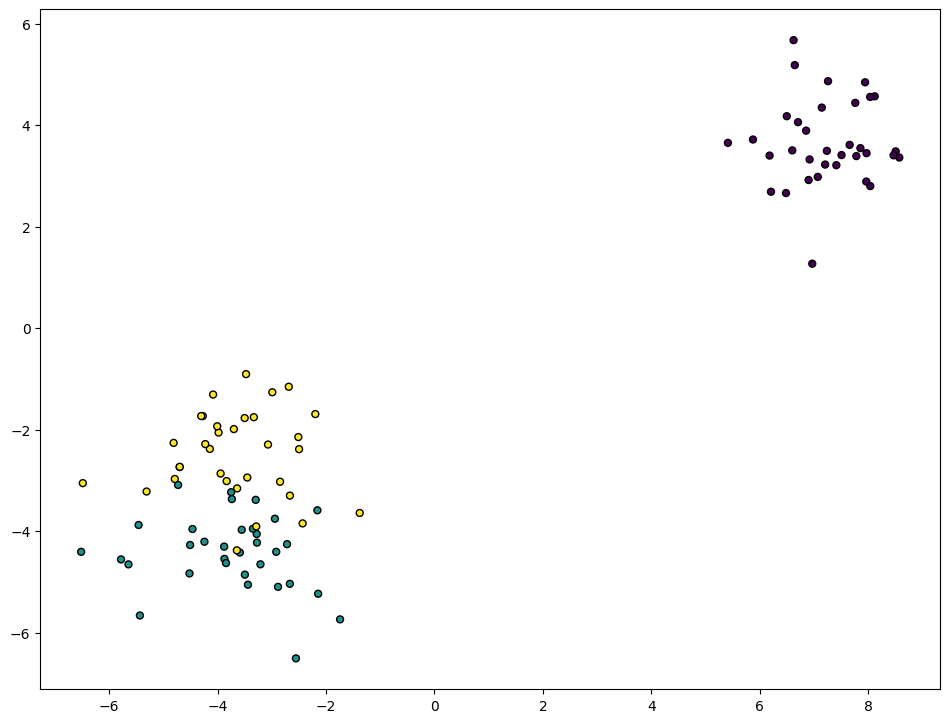

In [3]:
plt.figure(figsize=(10, 8))
plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)

X, Y_true = make_blobs()
plt.scatter(X[:, 0], X[:, 1], marker="o", c=Y_true, s=25, edgecolor="k")

2. Применить методы кластеризации K-Mean, MeanShift, DBSCAN
3. Померить качество кластеризации с помощью индекса Дунна. Так же измерить V-меру и Коэффициент силуэта.



In [4]:
def delta(ck, cl):
    values = np.ones([len(ck), len(cl)])
    for i in range(0, len(ck)):
        for j in range(0, len(cl)):
            values[i, j] = np.linalg.norm(ck[i]-cl[j])
    return np.min(values)

In [5]:
def DELTA(ci):
    values = np.zeros([len(ci), len(ci)])
    for i in range(0, len(ci)):
        for j in range(0, len(ci)):
            values[i, j] = np.linalg.norm(ci[i]-ci[j])
    return np.max(values)

In [6]:
def dunn(k_list):
    ds = np.ones([len(k_list), len(k_list)])
    Ds = np.zeros([len(k_list), 1])
    l_range = list(range(0, len(k_list)))
    for k in l_range:
        for l in (l_range[0:k]+l_range[k+1:]):
            ds[k, l] = delta(k_list[k], k_list[l])
            Ds[k] = DELTA(k_list[k])
            di = np.min(ds)/np.max(Ds)
    return di

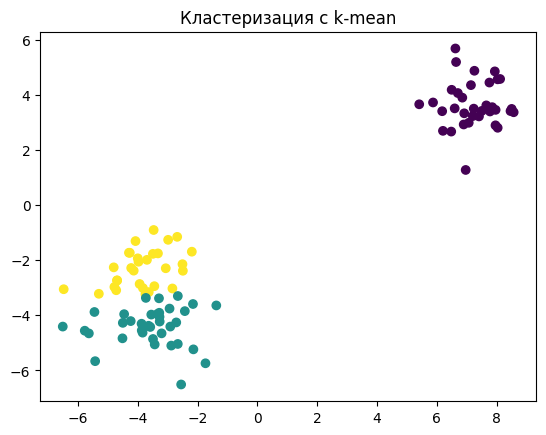

Силуэтный коэффициент: 0.5538753590330894
V-мера: 0.8020571929302228
Индекс Дунна: 0.026255163122266424


In [7]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters = 3, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Кластеризация с k-mean')
plt.show()

k_list = [X[labels == i] for i in range(kmeans.n_clusters)]

silhouette_avg = silhouette_score(X, labels)
v_measure = v_measure_score(Y_true, labels)
dunn_score = dunn(k_list)

print(f"Силуэтный коэффициент: {silhouette_avg}")
print(f"V-мера: {v_measure}")
print(f"Индекс Дунна: {dunn_score}")

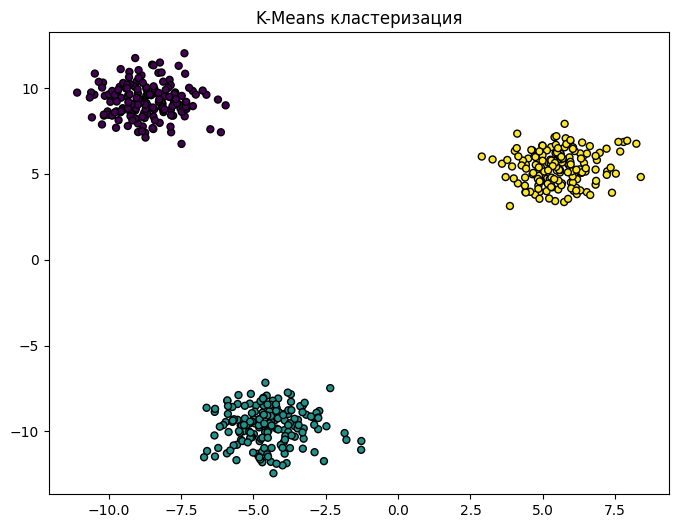

Силуэтный коэффициент: 0.887
V-мера: 1.000
Индекс Дунна: 0.169


In [20]:
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, v_measure_score
import matplotlib.pyplot as plt
import numpy as np

# X, y_true = make_classification(n_features=2, n_redundant=0, n_informative=2,
#                                 n_classes=1, n_clusters_per_class=3, shift=50, n_samples=500, class_sep=1.5)
X, Y_true = make_blobs(n_samples=500)
# plt.subplot(325)
# plt.title("Three blobs", fontsize="small")
# X, Y1 = make_blobs(n_features=2, centers=3)
# plt.scatter(X[:, 0], X[:, 1], marker="o", c=Y1, s=25, edgecolor="k")

n_clusters = len(np.unique(Y_true))  # количество кластеров = количество классов
kmeans = KMeans(n_clusters = 3)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=25, edgecolor="k")
plt.title("K-Means кластеризация")
plt.show()

silhouette_avg = silhouette_score(X, labels)
print(f"Силуэтный коэффициент: {silhouette_avg:.3f}")

v_measure = v_measure_score(Y_true, labels)
print(f"V-мера: {v_measure:.3f}")

k_list = [X[labels == i] for i in range(kmeans.n_clusters)]

# v_measure = v_measure_score(Y_true, labels)
dunn_score = dunn(k_list)

print(f"Индекс Дунна: {dunn_score:.3f}")


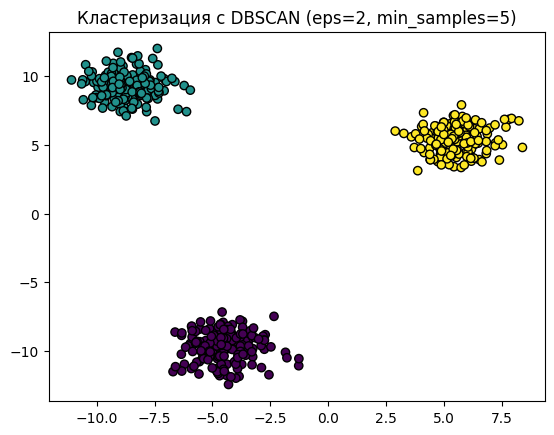

Силуэтный коэффициент: 0.8873025920455111
V-мера: 1.0
Индекс Дунна: 0.1685150057661307


In [21]:
from sklearn.cluster import DBSCAN

eps = 2 # радиус соседства
min_samples = 5 # минимальное количество точек в кластере
dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
labels = dbscan.labels_

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k')
plt.title(f'Кластеризация с DBSCAN (eps={eps}, min_samples={min_samples})')
plt.show()

unique_labels = np.unique(labels)


k_list = [X[labels == i] for i in range(len(unique_labels))]

# v_measure = v_measure_score(Y_true, labels)
dunn_score = dunn(k_list)
v_measure = v_measure_score(Y_true, labels)
silhouette_avg = silhouette_score(X, labels)

print(f"Силуэтный коэффициент: {silhouette_avg}")
print(f"V-мера: {v_measure}")
print(f"Индекс Дунна: {dunn_score}")


3


/tmp/ipykernel_57084/2835529770.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


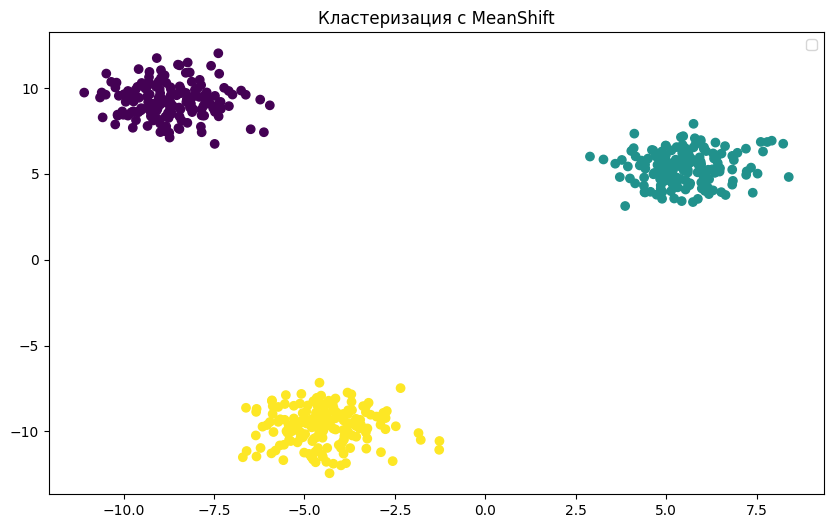

Силуэтный коэффициент: 0.8873025920455111
V-мера: 1.0
Индекс Дунна: 0.1685150057661307


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift

mean_shift = MeanShift()
labels = mean_shift.fit_predict(X)

unique_labels = np.unique(labels)
colors = plt.get_cmap('viridis', len(unique_labels))

plt.figure(figsize=(10, 6))

print(len(unique_labels))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Кластеризация с MeanShift')
plt.legend()
plt.show()

k_list = [X[labels == i] for i in range(len(unique_labels))]

dunn_score = dunn(k_list)
# V-мера (работает только если есть истинные метки)
v_measure = v_measure_score(Y_true, labels)
silhouette_avg = silhouette_score(X, labels)

print(f"Силуэтный коэффициент: {silhouette_avg}")
print(f"V-мера: {v_measure}")
print(f"Индекс Дунна: {dunn_score}")

4. Реализовать свой метод K-Mean. Провести сравнение с библиотечным.


Сходимость достигнута за 8 итераций.


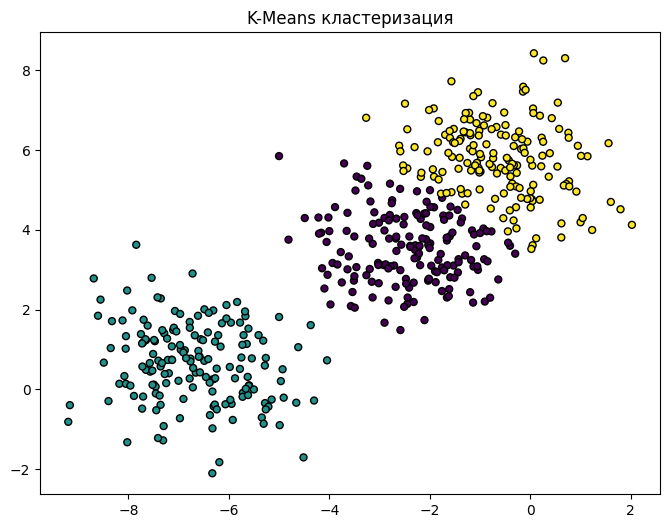

Силуэтный коэффициент: 0.523
V-мера: 0.830
Индекс Дунна: 0.017


In [23]:
import numpy as np

def kmeans(X, n_clusters, max_iter=300, tol=1e-4, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    n_samples, n_features = X.shape
    initial_indices = np.random.choice(n_samples, n_clusters, replace=False)
    centroids = X[initial_indices]

    for iteration in range(max_iter):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])

        if np.linalg.norm(new_centroids - centroids) < tol:
            print(f"Сходимость достигнута за {iteration} итераций.")
            break

        centroids = new_centroids

    return labels, centroids

X, Y_true = make_blobs(n_samples=500)
# plt.subplot(325)
# plt.title("Three blobs", fontsize="small")
# X, Y1 = make_blobs(n_features=2, centers=3)
# plt.scatter(X[:, 0], X[:, 1], marker="o", c=Y1, s=25, edgecolor="k")

n_clusters = len(np.unique(Y_true))  # количество кластеров = количество классов
labels, centroids = kmeans(X, n_clusters)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=25, edgecolor="k")
plt.title("K-Means кластеризация")
plt.show()

silhouette_avg = silhouette_score(X, labels)
print(f"Силуэтный коэффициент: {silhouette_avg:.3f}")

v_measure = v_measure_score(Y_true, labels)
print(f"V-мера: {v_measure:.3f}")

k_list = [X[labels == i] for i in range(n_clusters)]

# v_measure = v_measure_score(Y_true, labels)
dunn_score = dunn(k_list)

print(f"Индекс Дунна: {dunn_score:.3f}")

5. Сгенерировать набор данных высокой размерности (к примеру 15). Затем итеративно уменьшать размерность данных на 1 до размерности 2 и оценивать точность работы K-Mean. Сравнить точности. Возможно будет долго работать, тогда можно начать с размерности 12 или 10

Размерность: 15, Силуэтный коэффициент: 0.2755
Размерность: 14, Силуэтный коэффициент: 0.2801
Размерность: 13, Силуэтный коэффициент: 0.2848
Размерность: 12, Силуэтный коэффициент: 0.2906
Размерность: 11, Силуэтный коэффициент: 0.2981
Размерность: 10, Силуэтный коэффициент: 0.3083
Размерность: 9, Силуэтный коэффициент: 0.3214
Размерность: 8, Силуэтный коэффициент: 0.2376
Размерность: 7, Силуэтный коэффициент: 0.3625
Размерность: 6, Силуэтный коэффициент: 0.3877
Размерность: 5, Силуэтный коэффициент: 0.4258
Размерность: 4, Силуэтный коэффициент: 0.4757
Размерность: 3, Силуэтный коэффициент: 0.5678
Размерность: 2, Силуэтный коэффициент: 0.5176


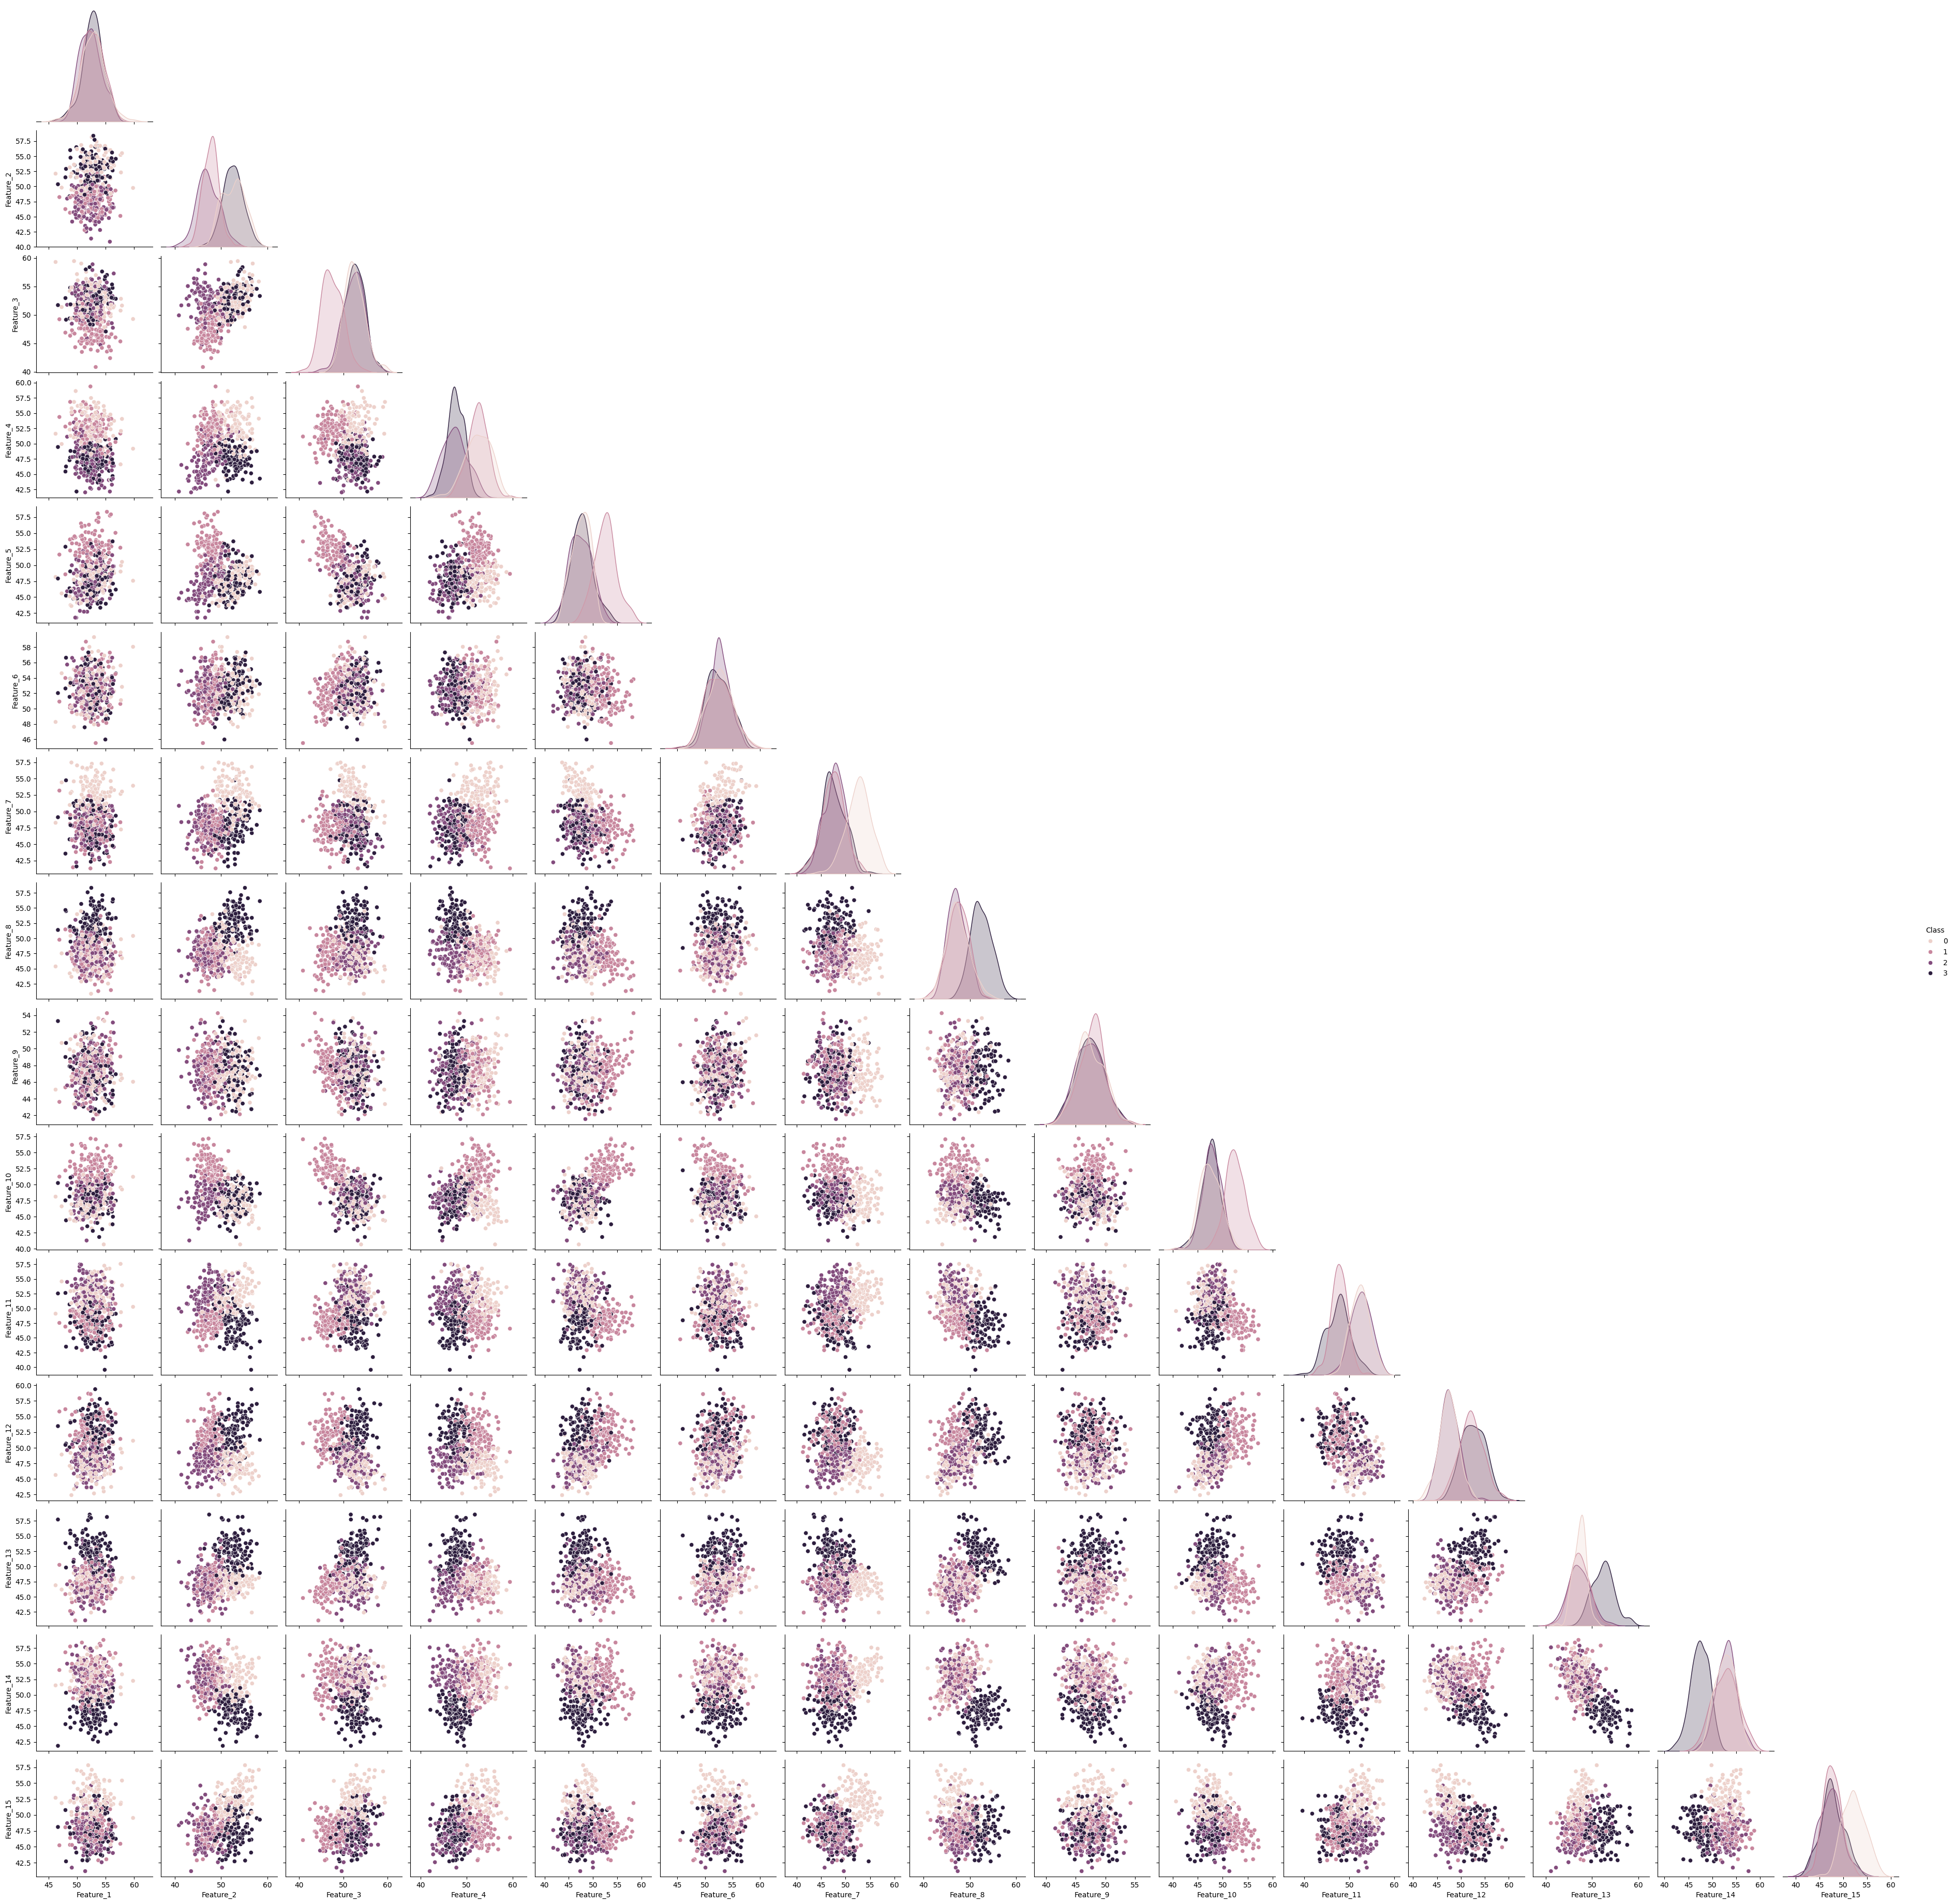

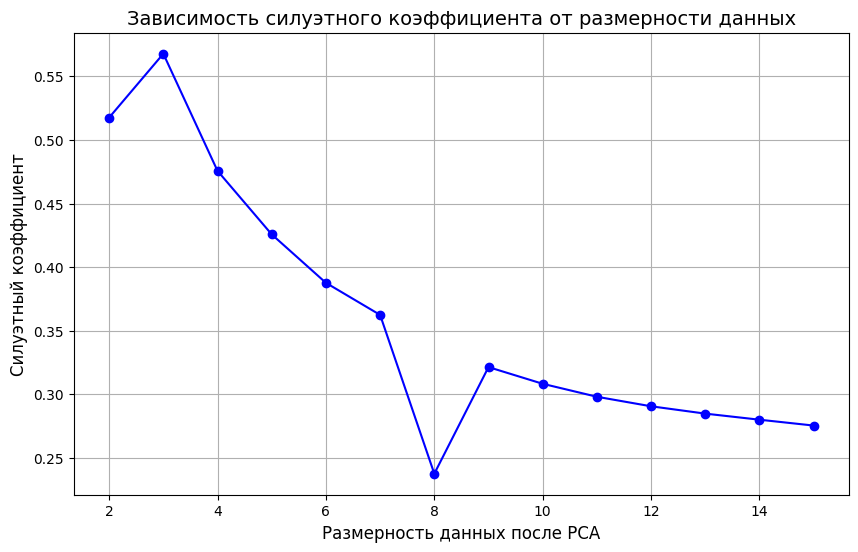

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

n_samples = 1000
n_features = 15 # Начальная размерность
n_clusters = 4
X, y_true = make_classification(n_features=n_features, n_redundant=0, n_informative=n_features,
                                n_classes=n_clusters, n_clusters_per_class=1, shift=50, n_samples=500, class_sep=2.5)
# X, y_true = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features, random_state=42)
dat1 = pd.DataFrame(X, columns = [[str(i) for i in range(n_features)]])
res1 = pd.DataFrame(y_true, columns = ['type'])
df = pd.DataFrame(X, columns=[f'Feature_{i+1}' for i in range(X.shape[1])])
df['Class'] = y_true
sns.pairplot(df, hue='Class', diag_kind='kde', corner=True)

silhouette_scores = []
dimensions = list(range(n_features, 1, -1))

for dim in dimensions:
    pca = PCA(n_components=dim)
    X_reduced = pca.fit_transform(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(X_reduced)
    labels = kmeans.labels_

    silhouette_avg = silhouette_score(X_reduced, labels)
    silhouette_scores.append(silhouette_avg)

    print(f"Размерность: {dim}, Силуэтный коэффициент: {silhouette_avg:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(dimensions, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title("Зависимость силуэтного коэффициента от размерности данных", fontsize=14)
plt.xlabel("Размерность данных после PCA", fontsize=12)
plt.ylabel("Силуэтный коэффициент", fontsize=12)
plt.grid(True)
plt.show()
